# Notebook 3 — SHAP Explainability

In [1]:
import pandas as pd
import numpy as np
import xgboost as xgb
import shap
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
import warnings
warnings.filterwarnings('ignore')

## 1. Load Model and Data

In [2]:
df = pd.read_csv('../data/processed_merged.csv')
ep = [c for c in df.columns if c.startswith('EP_')]
feature_cols = ep + ['IncidenceRate']

X = df[feature_cols].copy().replace(-999, np.nan).fillna(df[feature_cols].median())
y = df['rate']

_, X_test, _, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

model = xgb.XGBRegressor()
model.load_model('../data/xgb_final_model.json')
print('Model loaded. Test samples:', len(X_test))

Model loaded. Test samples: 387


## 2. Compute SHAP Values

In [3]:
explainer   = shap.TreeExplainer(model)
shap_values = explainer.shap_values(X_test)
print('SHAP values shape:', shap_values.shape)

SHAP values shape: (387, 25)


## 3. Feature Importance Bar Chart

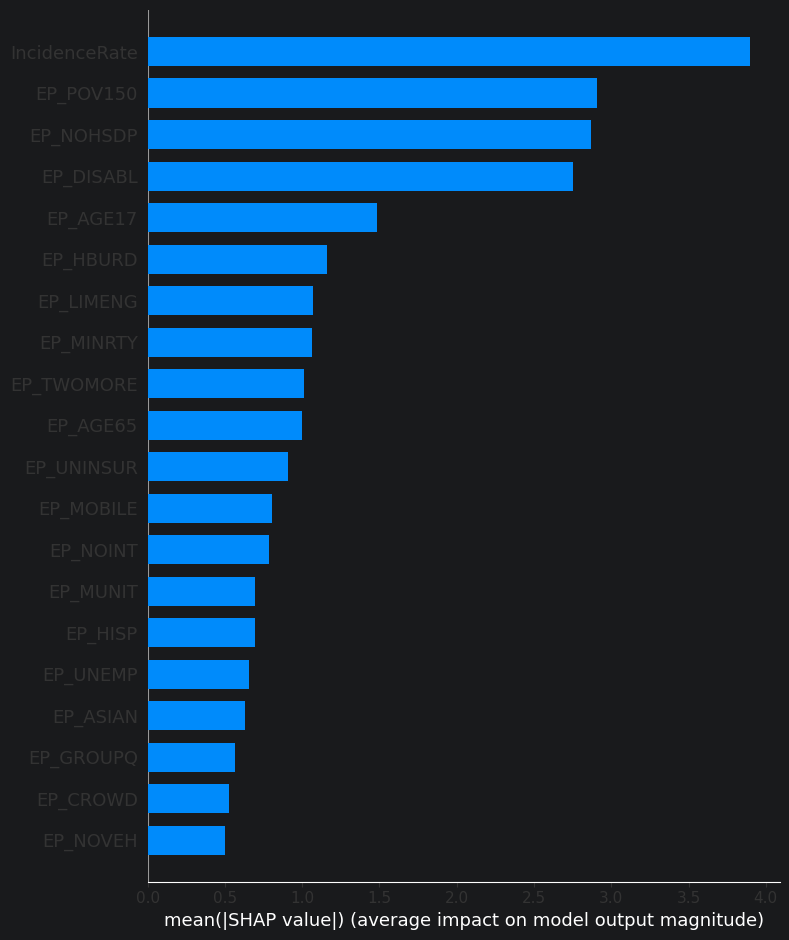

In [4]:
plt.figure()
shap.summary_plot(shap_values, X_test, plot_type='bar', show=False)
plt.tight_layout()
plt.savefig('../visualizations/shap_feature_importance.png', dpi=150, bbox_inches='tight')
plt.show()

## 4. Beeswarm Plot

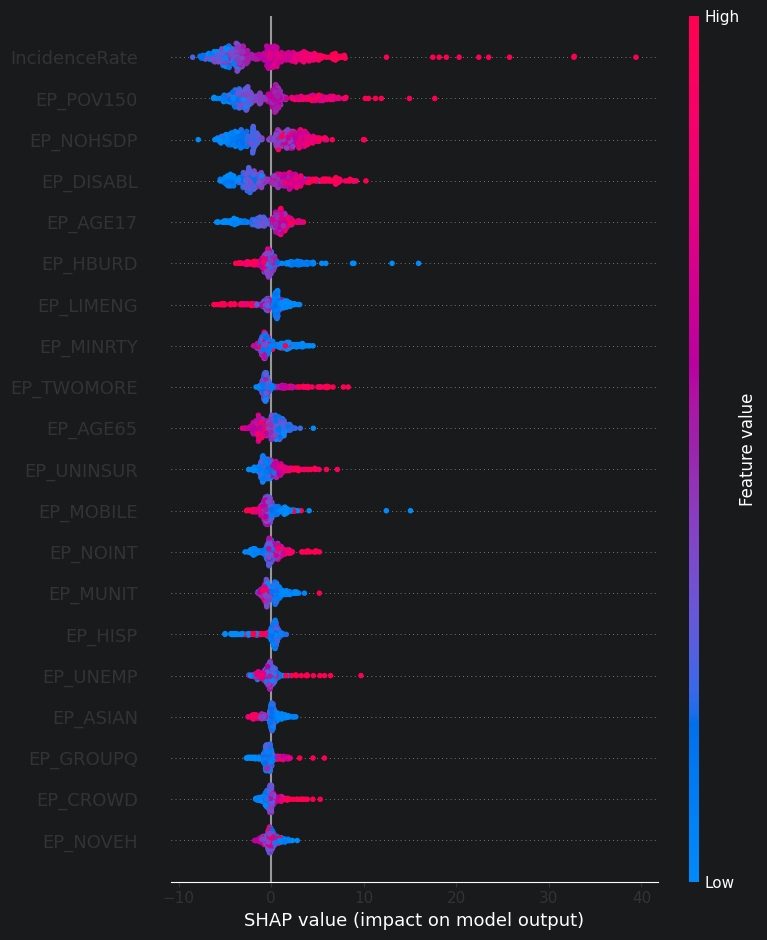

In [5]:
plt.figure()
shap.summary_plot(shap_values, X_test, show=False)
plt.tight_layout()
plt.savefig('../visualizations/shap_beeswarm.png', dpi=150, bbox_inches='tight')
plt.show()

## 5. Key Findings Table

In [6]:
mean_shap = pd.DataFrame({
    'Feature': feature_cols,
    'Mean |SHAP|': np.abs(shap_values).mean(axis=0)
}).sort_values('Mean |SHAP|', ascending=False).reset_index(drop=True)

directions = []
for feat in mean_shap['Feature']:
    idx = list(feature_cols).index(feat)
    high_mask = X_test[feat] > X_test[feat].median()
    avg_shap_high = shap_values[high_mask, idx].mean()
    directions.append('Higher → Higher mortality' if avg_shap_high > 0 else 'Higher → Lower mortality')
mean_shap['Direction'] = directions

print(mean_shap.head(10).to_string(index=False))
mean_shap.to_csv('../data/shap_key_findings.csv', index=False)
print('\nSaved: shap_key_findings.csv')

      Feature  Mean |SHAP|                 Direction
IncidenceRate     3.897067 Higher → Higher mortality
    EP_POV150     2.908993 Higher → Higher mortality
    EP_NOHSDP     2.866585 Higher → Higher mortality
    EP_DISABL     2.753017 Higher → Higher mortality
     EP_AGE17     1.481497 Higher → Higher mortality
     EP_HBURD     1.161798  Higher → Lower mortality
    EP_LIMENG     1.067855  Higher → Lower mortality
    EP_MINRTY     1.060522  Higher → Lower mortality
   EP_TWOMORE     1.009023 Higher → Higher mortality
     EP_AGE65     0.996433  Higher → Lower mortality

Saved: shap_key_findings.csv
